In [1]:
!pwd

/mnt/c/Users/vvasileiou/Desktop/lncAPNet/Pilot_2_Prostate/notebooks/Post-hoc_Analysis


In [2]:
import pandas as pd
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import math

In [3]:
####################################################
## Clinical Covariates ##
####################################################

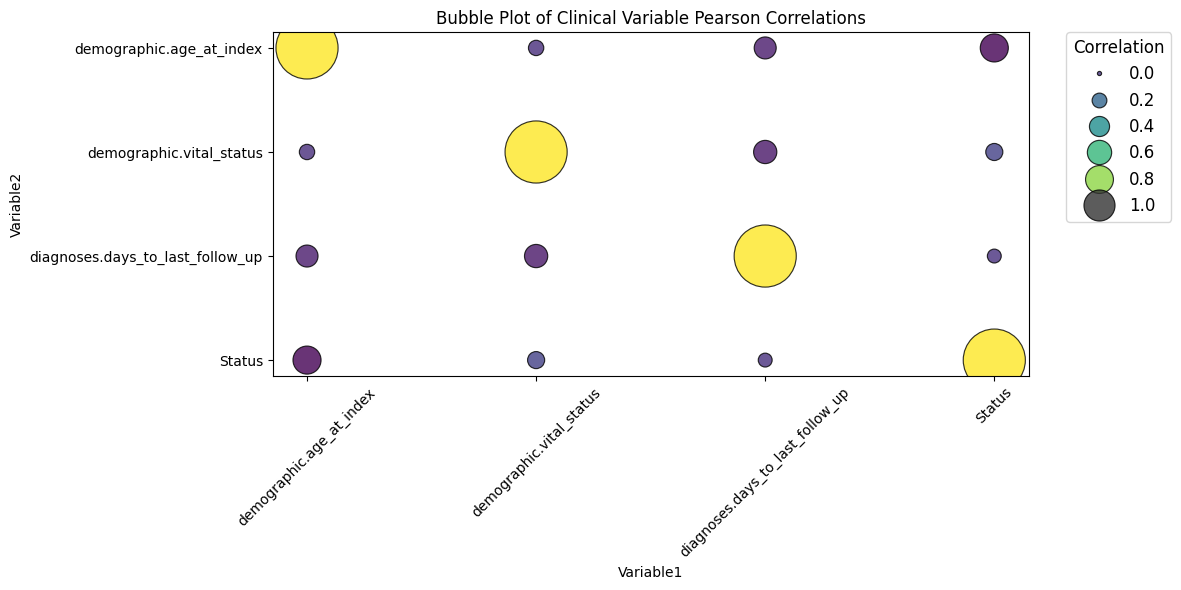

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## BCMO
# Load data
clinical = pd.read_excel("../../data/TCGA/clinical_info.xlsx")

# Select columns of interest and make a copy to avoid SettingWithCopyWarning
cols_of_interest = ["demographic.age_at_index", "demographic.vital_status", 
                    "diagnoses.days_to_last_follow_up", "Status"]
clinical_subset = clinical[cols_of_interest].copy()

# Encode categorical columns to numeric
clinical_subset['Status'] = clinical_subset['Status'].map({'Progressive': 0, 'Mild': 1})
clinical_subset['demographic.vital_status'] = clinical_subset['demographic.vital_status'].map({'Dead': 0, 'Alive': 1})

# Compute correlation matrix
corr_matrix = clinical_subset.corr()

# Melt for plotting
corr_long = corr_matrix.reset_index().melt(id_vars='index')
corr_long.columns = ['Variable1', 'Variable2', 'Correlation']

# Bubble plot
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=corr_long,
    x='Variable1',
    y='Variable2',
    size=corr_long['Correlation'].abs(),  # size by magnitude
    hue='Correlation',                    # color by sign
    sizes=(100, 2000),
    palette='viridis',
    alpha=0.8,
    edgecolor='k'
)

# Rotate x-axis labels
plt.xticks(rotation=45)
plt.title("Bubble Plot of Clinical Variable Pearson Correlations")

# Adjust legend
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc=2,
    borderaxespad=0.,
    title='Correlation',
    fontsize=12,
    title_fontsize=12,
    markerscale=0.5
)

# Ensure labels are not cut off
plt.tight_layout()

# Save figure
plt.savefig("../../figures/Clinical_Covariates.png", dpi=300, bbox_inches='tight')
plt.show()


In [5]:
####################################################
## Kaplan Meiers ##
####################################################

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

def kaplan_meier_plots(
    clinical_file,
    expr_file,
    genes,
    output_file,
    split_method="median",
    fig_title=None,
    time_col=None
):
    """
    Generate Kaplan-Meier survival plots for a list of genes.

    Parameters:
    - clinical_file: path to clinical CSV/Excel (must have Sample_ID and Status)
    - expr_file: path to expression/activity CSV (genes x samples)
    - genes: list of gene names to analyze
    - output_file: path to save the figure
    - split_method: "median" or "quartile"
    - fig_title: string for the figure-wide title (optional)
    - time_col: name of the time column in clinical data
    """
    # 1. Load clinical data
    clinical = pd.read_excel(clinical_file)
    
    # Keep only necessary columns
    clinical = clinical[['Sample_ID', 'demographic.vital_status', time_col]].copy()
    
    # Map status to binary (1=Dead, 0=Alive)
    clinical['Status'] = clinical['demographic.vital_status'].map({'Dead': 1, 'Alive': 0})
    
    # Convert time_col to numeric, coerce errors to NaN
    clinical[time_col] = pd.to_numeric(clinical[time_col], errors='coerce')
    
    # Drop rows with missing Status or time
    clinical = clinical.dropna(subset=['Status', time_col])
    
    # 2. Load expression/activity matrix
    expr = pd.read_csv(expr_file, index_col=0)
    
    # 3. Determine subplot grid size dynamically
    n_genes = len(genes)
    n_cols = 2
    n_rows = math.ceil(n_genes / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 9 * n_rows))
    axes = axes.flatten()
    
    # 4. Figure-wide title
    if fig_title is None:
        title_map = {
            "median": "Survival Analysis of ICGC for ALL Genes -- ACTIVITY",
            "quartile": "Survival Analysis of ICGC for Quartile Genes (Activity)"
        }
        fig_title = title_map.get(split_method, "Survival Analysis")
    fig.suptitle(fig_title, fontsize=30, y=1.02)
    
    # 5. Loop through genes
    for i, gene in enumerate(genes):
        ax = axes[i]
        
        if gene not in expr.index:
            ax.text(0.5, 0.5, f"{gene} not found", ha='center', va='center', fontsize=14)
            ax.axis('off')
            continue
        
        # Extract gene activity
        gene_activity = expr.loc[gene].rename("Activity")
        
        # Merge with clinical data
        df = clinical.merge(gene_activity, left_on="Sample_ID", right_index=True)
        
        # Define High/Low groups
        if split_method == "median":
            df[f"{gene}_group"] = (df["Activity"] > df["Activity"].median()).map({True: "High", False: "Low"})
            df_to_use = df
        elif split_method == "quartile":
            q_low = df["Activity"].quantile(0.25)
            q_high = df["Activity"].quantile(0.75)
            df_to_use = df[(df["Activity"] <= q_low) | (df["Activity"] >= q_high)].copy()
            df_to_use[f"{gene}_group"] = df_to_use["Activity"].apply(lambda x: "High" if x >= q_high else "Low")
        else:
            raise ValueError("split_method must be 'median' or 'quartile'")
        
        # Drop rows with missing values in group, Status, or time
        df_to_use = df_to_use.dropna(subset=[f"{gene}_group", "Status", time_col])
        
        # Kaplan–Meier plot
        kmf = KaplanMeierFitter()
        for group, grouped_df in df_to_use.groupby(f"{gene}_group"):
            kmf.fit(grouped_df[time_col], grouped_df["Status"], label=group)
            kmf.plot_survival_function(ax=ax, ci_show=True)
        
        # Log-rank test
        high = df_to_use[df_to_use[f"{gene}_group"] == "High"]
        low = df_to_use[df_to_use[f"{gene}_group"] == "Low"]
        if len(high) > 0 and len(low) > 0:
            results = logrank_test(
                high[time_col], low[time_col],
                event_observed_A=high["Status"], event_observed_B=low["Status"]
            )
            pval = results.p_value
        else:
            pval = np.nan
        
        # Format p-value
        if pd.isna(pval):
            pval_str = "NA"
        elif pval >= 0.005:
            pval_str = f"{pval:.4f}"
        else:
            pval_str = f"{pval:.1e}".replace("e-0", "e-").replace("e", "×10")

        # Set subplot title and labels
        ax.set_title(f"{gene} (p = {pval_str})", fontsize=25)
        ax.set_xlabel(f"Time from Sampling ({time_col})", fontsize=16)
        ax.set_ylabel("Overall Survival Probability", fontsize=16)
        ax.tick_params(axis='both', labelsize=14)
        ax.legend(fontsize=14)
    
    # Remove unused axes if any
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
    
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    plt.show()


In [7]:
# For Survival STATUS (OS)

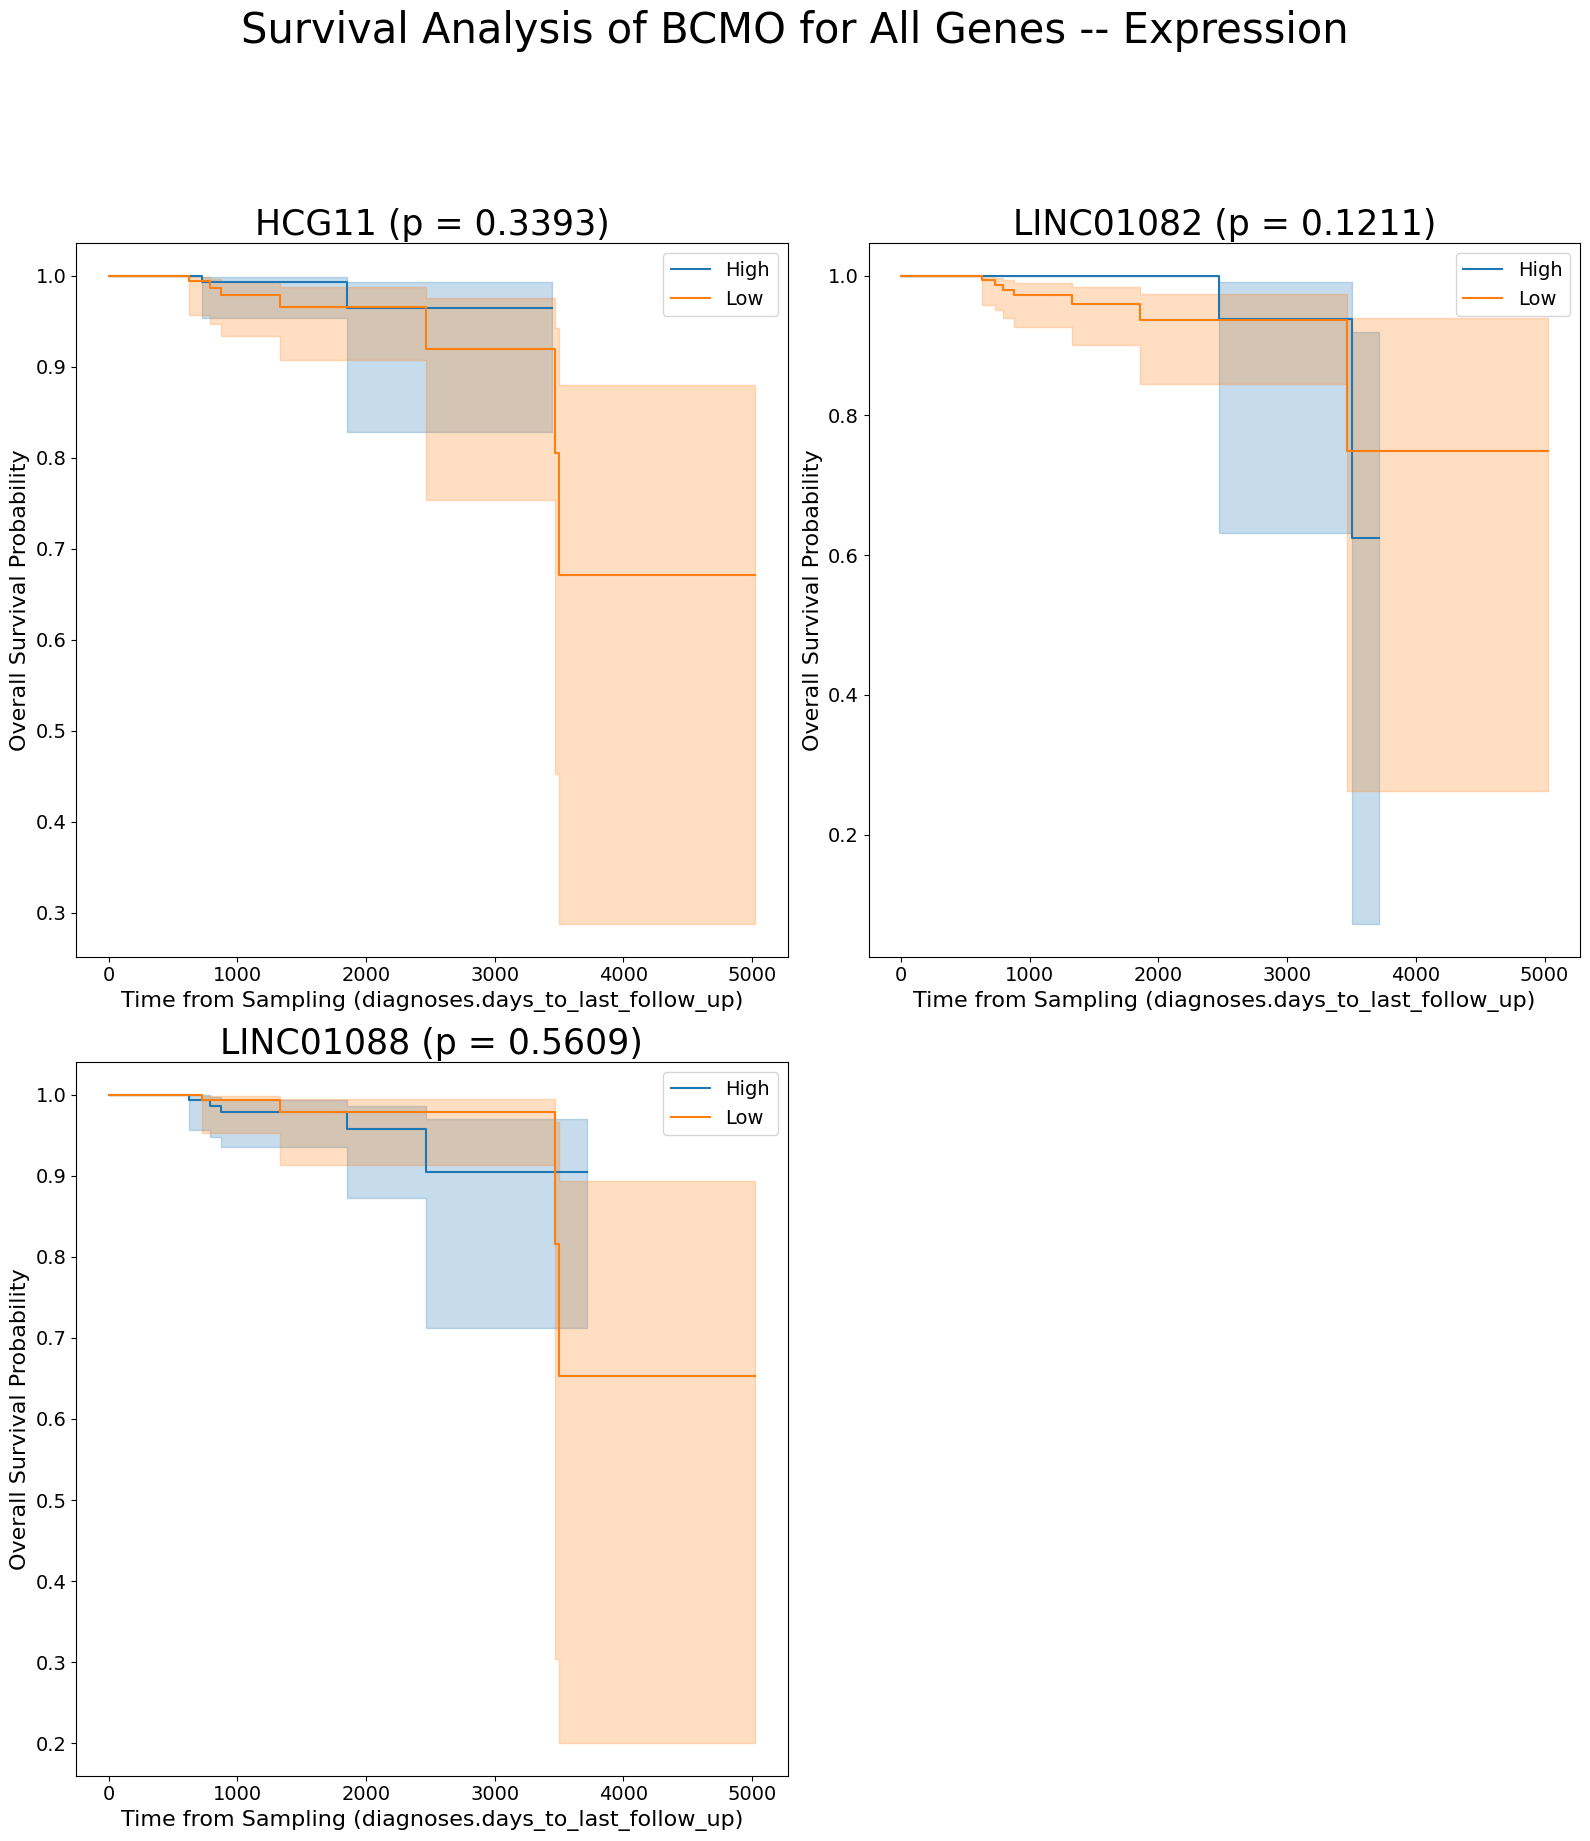

In [9]:
# Example usage
genes = ["HCG11_NC", "LINC01082", "LINC01088"]

kaplan_meier_plots(
    clinical_file="../../data/TCGA/clinical_info.xlsx",
    expr_file="../../data/TCGA/activity_ens.csv",
    genes=genes,
    output_file="../../figures/KaplanMeier_OS_all_genes_TCGA_expression.png",
    split_method="median",
    fig_title="Survival Analysis of BCMO for All Genes -- Expression",
    time_col="diagnoses.days_to_last_follow_up"
)